In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix


import HelpfulFunctions as hp
iris = load_iris()
%matplotlib inline

### 1. Load the data

In [2]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 2. Case Study : we want to predict 'virginica'

In [3]:
y = iris.target
y = (np.array(y)==2).astype(int)

Sepal Length and Sepal Width as Features

c:\Users\33659\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


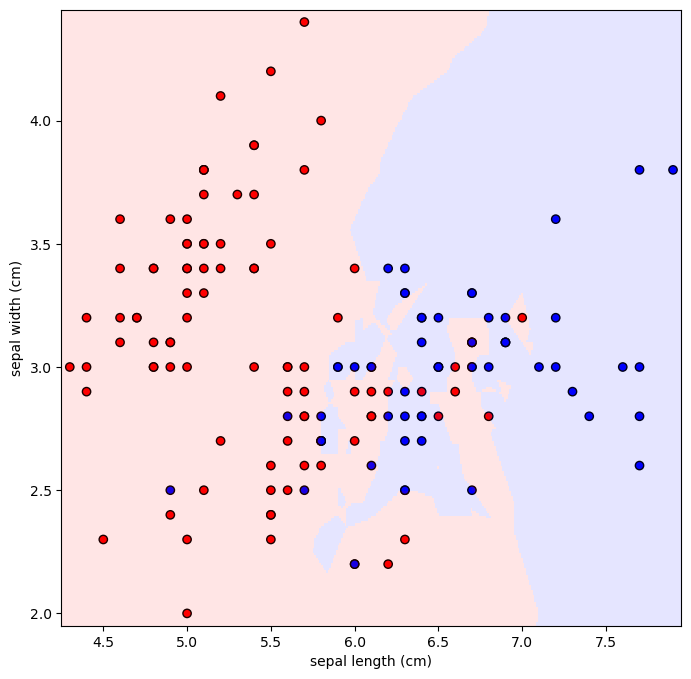

In [4]:
featureX = 'sepal length (cm)'
featureY = 'sepal width (cm)'

X_2 = df[[featureX,featureY]]

K=3
clf = KNeighborsClassifier(K)
clf.fit(X_2, y)

plt.figure(figsize=(8, 8))
hp.featureSpacePlot(featureX,featureY,df,y,clf,plt);

In [5]:
y_pred = clf.predict(X_2)
confusion_matrix(y, y_pred)

array([[89, 11],
       [12, 38]], dtype=int64)

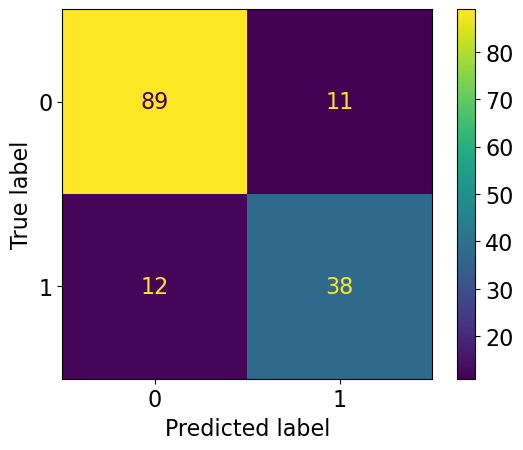

In [6]:
hp.plot_cm(clf, X_2, y, labels=['not virginica','virginica'])

We change the weights

* before we used “uniform” weights : all points have the same weight

 * now we use “distance” weughts : define an an inverse distance weight

c:\Users\33659\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


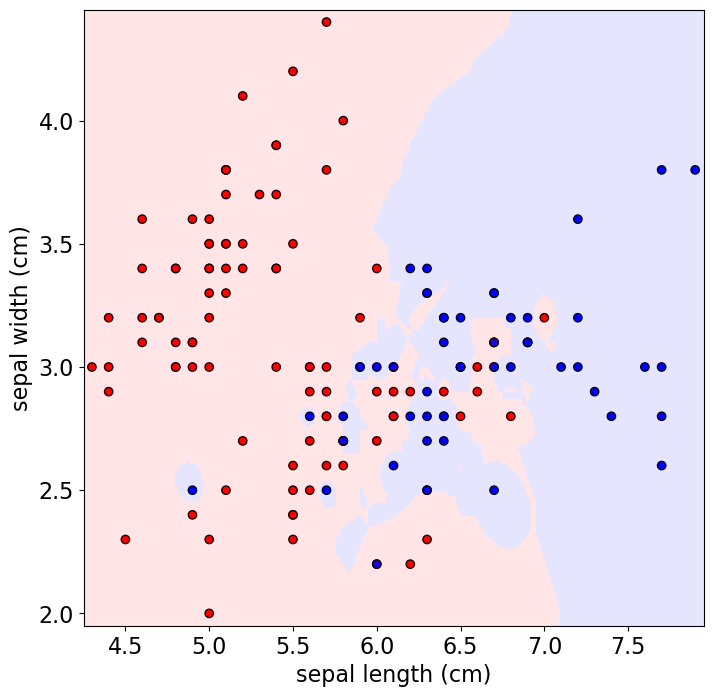

In [7]:
K=3
clf = KNeighborsClassifier(K, weights="distance")
clf.fit(X_2, y)
plt.figure(figsize=(8, 8))
hp.featureSpacePlot(featureX,featureY,X_2,y,clf,plt);

In [8]:
y_pred = clf.predict(X_2)
cm = confusion_matrix(y, y_pred)
print(cm)

[[99  1]
 [10 40]]


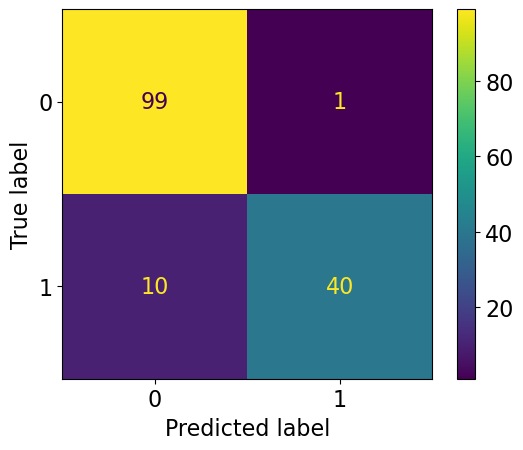

In [9]:
hp.plot_cm(clf, X_2, y, labels=['not virginica','virginica'])

With distance weights, we find much more accurate results

Now lets see the influence of K

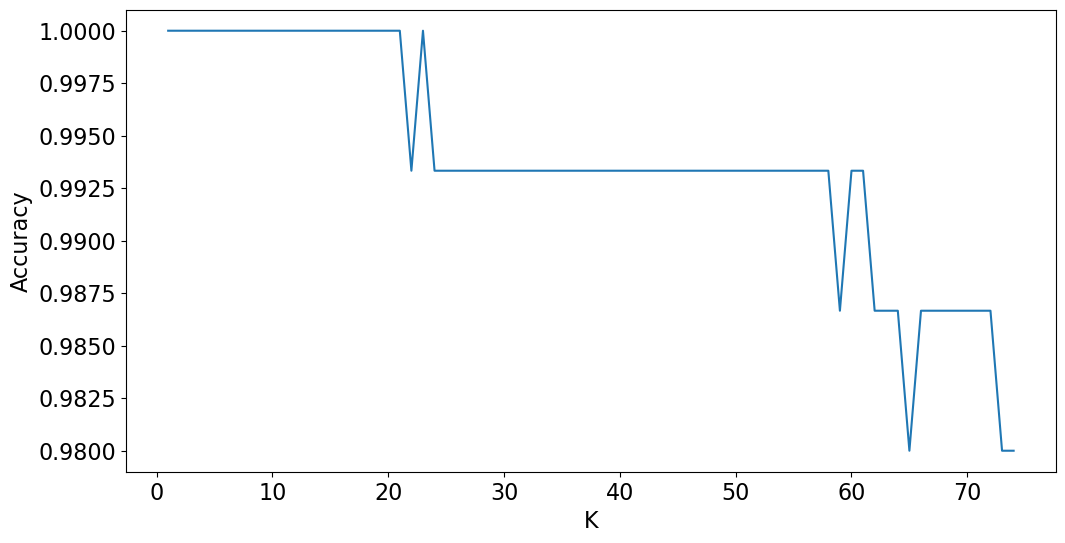

In [10]:
accs = []
ks = []

# Fails if k > 74
for k in range(1,75,1):
    knn = KNeighborsClassifier(n_neighbors = k, p=2)
    knn.fit(df, y)
    y_pred = knn.predict(df)
    cm = confusion_matrix(y, y_pred)
    acc = knn.score(df,y)
    ks.append(k)
    accs.append(acc)
    
plt.figure(figsize=(12, 6))
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.plot(ks,accs);

### 3. Multiclass classification

Let us examine all of the Feature Space Decision Boundaries

In each case we will fit using each combination of the features shown

c:\Users\33659\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


<module 'matplotlib.pyplot' from 'c:\\Users\\33659\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

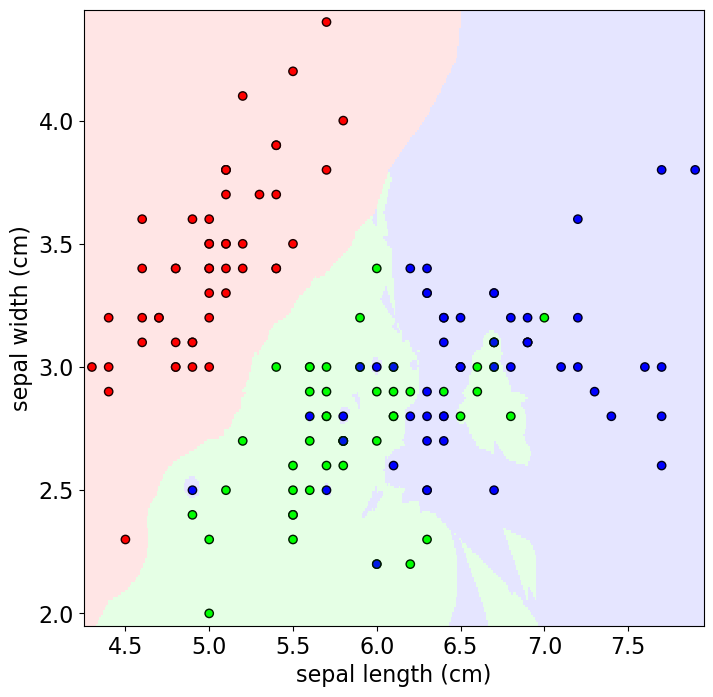

In [15]:
featureX = 'sepal length (cm)'
featureY = 'sepal width (cm)'

X_2 = df[[featureX,featureY]]
y = iris.target

K=10
clf = KNeighborsClassifier(K,weights='distance')
clf.fit(X_2, y)

plt.figure(figsize=(8, 8))
hp.featureSpacePlot(featureX,featureY,X_2,y,clf,plt)

In [16]:
y_pred = clf.predict(X_2)
cm = confusion_matrix(y, y_pred)
print(cm)

[[50  0  0]
 [ 0 49  1]
 [ 0 10 40]]


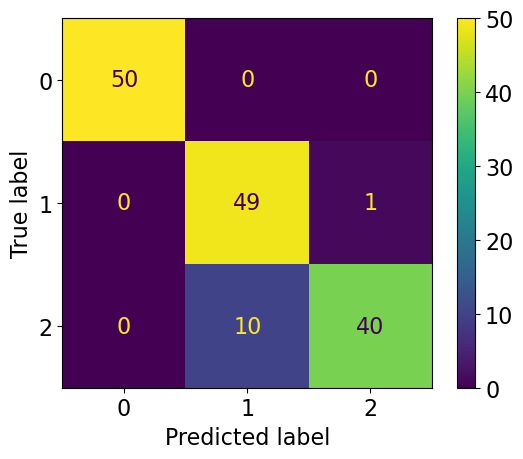

In [17]:
hp.plot_cm(clf, X_2, y, labels=iris.target_names)